In [61]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.offsetbox import BboxImage
from matplotlib.transforms import Bbox
from matplotlib.gridspec import GridSpec
from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Helvetica']

import numpy as np
import pandas as pd
import pickle
import pyvista as pv
from mat4py import loadmat
from scipy.stats import boxcox
from scipy.special import inv_boxcox
import glob

import jax.numpy as jnp
from train_diffusion import *
import jax.random as random
rng = random.PRNGKey(2025)

import seaborn as sns

from train_bitflip_diff import *
from train_diffusion_val import *
from calculate_nutrition import hei_calculator, calculate_bhnds

import os
usda_api_key = os.environ["MY_USDA_API_KEY"]
from usda_fdc import FdcClient

sampling_batch_size = 10000

def numeric_only(arr):
    return np.array(
        [x for x in arr if isinstance(x, (int, float, np.number))],
        dtype=float
    )
def to_feature_dict(unique_output):
    features, counts = unique_output
    return dict(zip(features, counts))

In [51]:
data_overall = pd.read_csv('data/survey/allburgers_overall_liking.csv')
data_flavor = pd.read_csv('data/survey/allburgers_flavor.csv')
data_texture = pd.read_csv('data/survey/allburgers_texture.csv')
data_flavor_features = pd.read_csv('data/survey/allburgers_flavor_features.csv')
data_texture_features = pd.read_csv('data/survey/allburgers_texture_features.csv')

column_names = ['delicious burger #1', 'delicious burger #2', 'sustainable burger #1', 'sustainable burger #2', 'nutritious burger', 'big mac']
# Rename the columns in all of the dataframes to simpler strings
for df in [data_overall, data_flavor, data_texture, data_flavor_features, data_texture_features]:
    new_columns = []
    for col in df.columns:
        renamed = col
        for target in column_names:
            if target in col.lower():
                renamed = target
                break
        new_columns.append(renamed)
    df.columns = new_columns

# Replace the likert-type answers to numeric
for df in [data_overall, data_flavor, data_texture]:
    mapping = {
        "Dislike very much": 1,
        "Dislike": 2,
        "Dislike somewhat": 3,
        "Neither like nor dislike": 4,
        "Like somewhat": 5,
        "Like": 6,
        "Like very much": 7,
    }
    df.replace(mapping, inplace=True)

# For CATA-type questions convert the outputs to collapsed lists
flavor_features = {
    'delicious burger #1': [],
    'delicious burger #2': [],
    'big mac': [],
    'nutritious burger': [],
    'sustainable burger #1': [],
    'sustainable burger #2': [],
}
texture_features = {
    'delicious burger #1': [],
    'delicious burger #2': [],
    'big mac': [],
    'nutritious burger': [],
    'sustainable burger #1': [],
    'sustainable burger #2': [],
}

for column in column_names:
    responses = data_flavor_features[column].to_numpy()
    for response in responses:
        response = response.split(',')
        for feature in response:
            feature = feature.strip()
            flavor_features[column].append(feature)
    flavor_features[column] = np.unique(flavor_features[column], return_counts=True)

for column in column_names:
    responses = data_texture_features[column].to_numpy()
    for response in responses:
        response = response.split(',')
        for feature in response:
            feature = feature.strip()
            texture_features[column].append(feature)
    texture_features[column] = np.unique(texture_features[column], return_counts=True)

# 1. Some trials

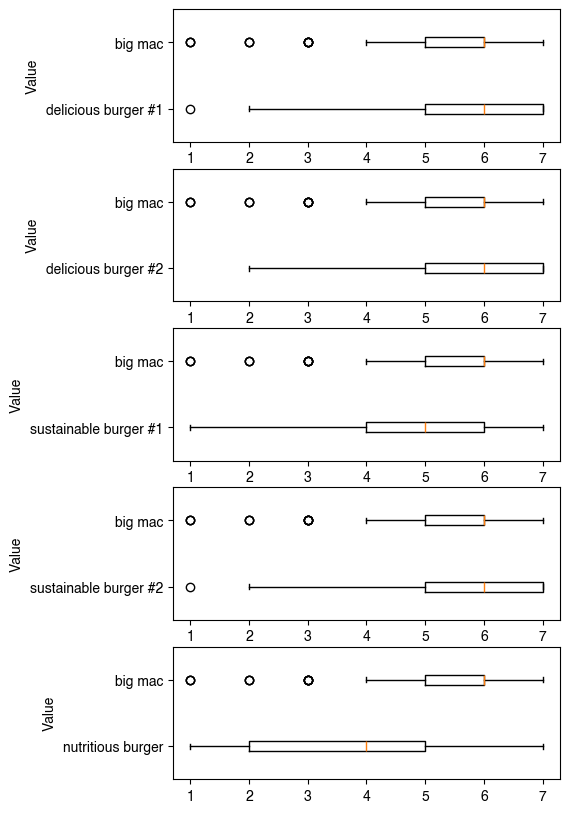

In [67]:
# Columns to compare against Big Mac
compare_cols = [
    "delicious burger #1",
    "delicious burger #2",
    "sustainable burger #1",
    "sustainable burger #2",
    "nutritious burger",
]

reference_col = "big mac"

fig, axes = plt.subplots(5,1,figsize=(5,10))
for col, ax in zip(compare_cols, axes):
    data_col = pd.to_numeric(data_overall[col], errors="coerce").dropna()
    data_ref = pd.to_numeric(data_overall[reference_col], errors="coerce").dropna()

    ax.boxplot(
        [
            data_col,
            data_ref
        ],
        tick_labels=[col, reference_col],
        showfliers=True,
        vert=False
    )

    # ax.set_title(f"{col} vs Big Mac")
    ax.set_ylabel("Value")


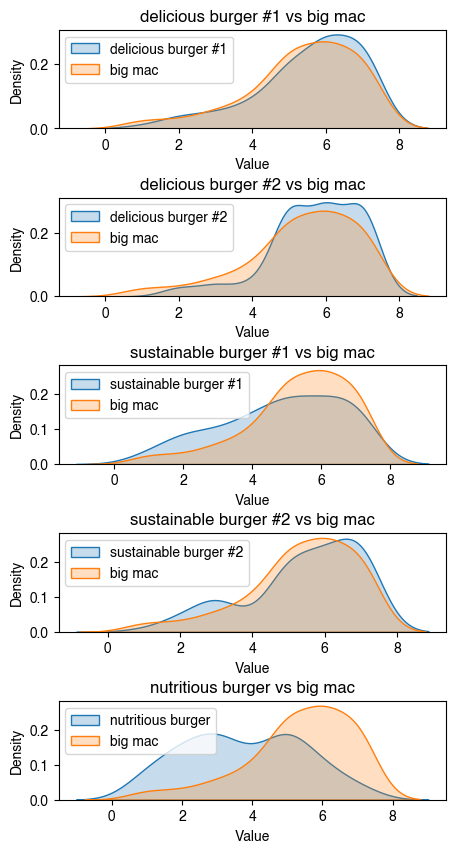

In [80]:
fig, axes = plt.subplots(5,1,figsize=(5,10))
fig.subplots_adjust(hspace=0.7)
for col, ax in zip(compare_cols, axes):
    data_col = pd.to_numeric(data[col], errors="coerce").dropna()
    data_ref = pd.to_numeric(data[reference_col], errors="coerce").dropna()

    sns.kdeplot(data_col, label=col, fill=True, ax=ax)
    sns.kdeplot(data_ref, label=reference_col, fill=True, ax=ax)

    ax.set(title=f"{col} vs big mac", xlabel="Value", ylabel="Density")
    ax.legend()

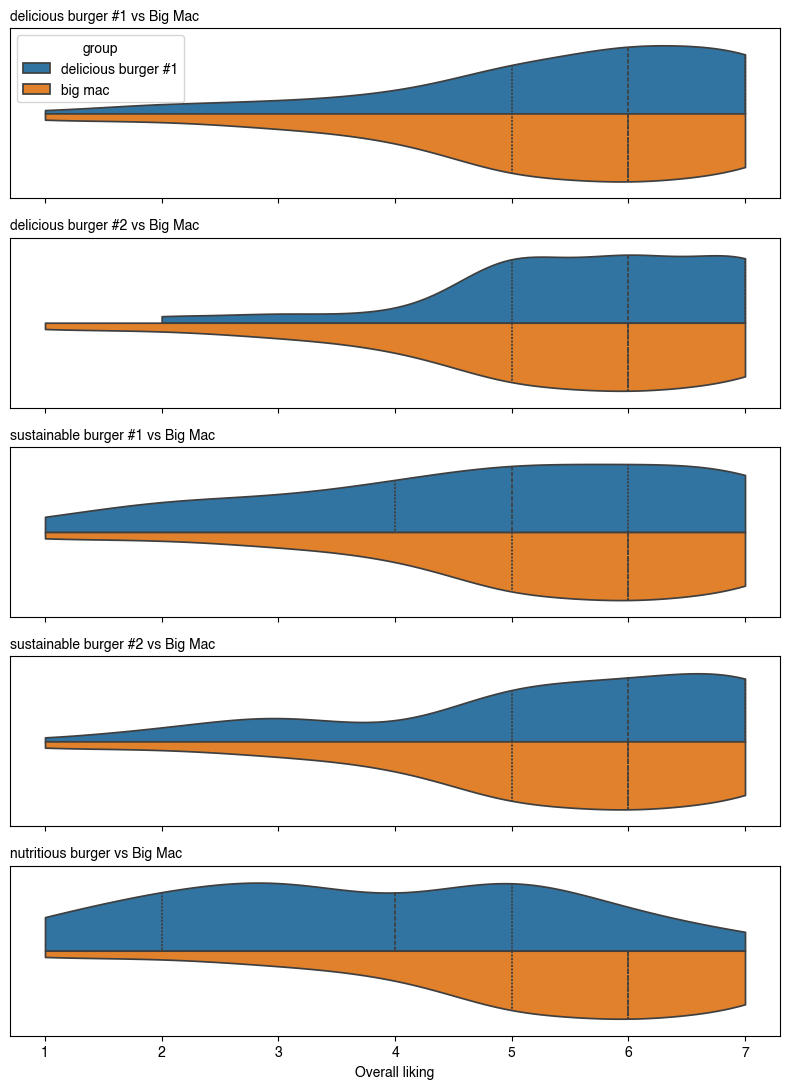

In [110]:
fig, axes = plt.subplots(
    nrows=len(compare_cols),
    ncols=1,
    figsize=(8, 2.2 * len(compare_cols)),
    sharex=True
)

for ax, col in zip(axes, compare_cols):
    # Clean data
    data_col = pd.to_numeric(data[col], errors="coerce").dropna()
    data_ref = pd.to_numeric(data[reference_col], errors="coerce").dropna()

    # Long-form dataframe
    plot_df = pd.DataFrame({
        "value": pd.concat([data_col, data_ref], ignore_index=True),
        "group": (
            [col] * len(data_col) +
            [reference_col] * len(data_ref)
        ),
        "panel": "comparison"  # dummy category required for split violins
    })

    sns.violinplot(
        data=plot_df,
        x="value",
        y="panel",
        hue="group",
        orient="h",
        split=True,
        cut=0,
        inner="quartile",
        ax=ax
    )

    ax.set_yticks([])
    ax.set_ylabel("")
    ax.set_title(f"{col} vs Big Mac", loc="left", fontsize=10)

    # Keep legend only on the first subplot
    if ax != axes[0]:
        ax.get_legend().remove()

axes[-1].set_xlabel("Overall liking")

plt.tight_layout()
plt.show()

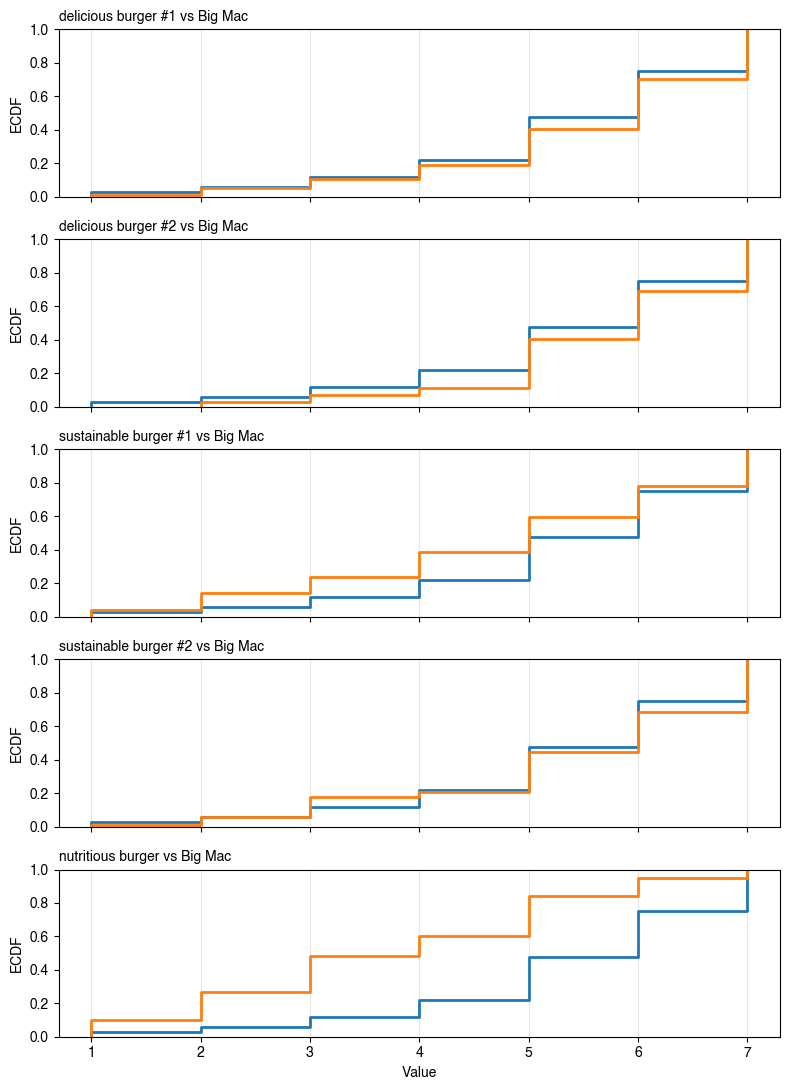

In [114]:
fig, axes = plt.subplots(
    nrows=len(compare_cols),
    ncols=1,
    figsize=(8, 2.2 * len(compare_cols)),
    sharex=True,
    sharey=True
)

for ax, col in zip(axes, compare_cols):
    # Clean data
    data_col = pd.to_numeric(data[col], errors="coerce").dropna()
    data_ref = pd.to_numeric(data[reference_col], errors="coerce").dropna()

    # ECDFs (horizontal)
    sns.ecdfplot(
        data=data_ref,
        ax=ax,
        # orient="h",
        label="Big Mac",
        linewidth=2
    )

    sns.ecdfplot(
        data=data_col,
        ax=ax,
        # orient="h",
        label=col,
        linewidth=2
    )

    ax.set_title(f"{col} vs Big Mac", loc="left", fontsize=10)
    ax.set_ylabel("ECDF")
    ax.grid(True, axis="x", alpha=0.3)

    # Keep legend only once
    # if ax != axes[0]:
    #     ax.get_legend().remove()

axes[-1].set_xlabel("Value")

plt.tight_layout()
plt.show()

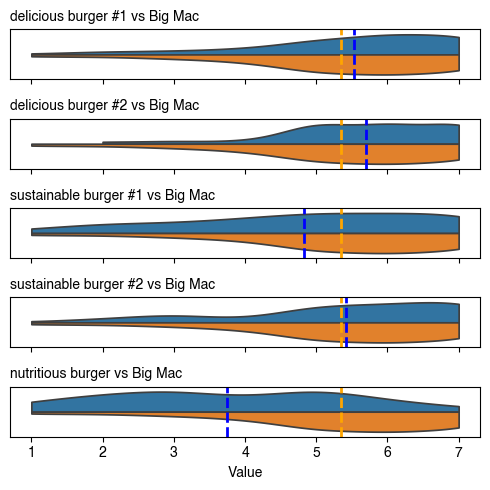

In [120]:
fig, axes = plt.subplots(
    nrows=len(compare_cols),
    ncols=1,
    figsize=(5, len(compare_cols)),
    sharex=True
)

for ax, col in zip(axes, compare_cols):
    # Clean data
    data_col = pd.to_numeric(data[col], errors="coerce").dropna()
    data_ref = pd.to_numeric(data[reference_col], errors="coerce").dropna()

    # Combine into long-form dataframe for seaborn
    plot_df = pd.DataFrame({
        "value": pd.concat([data_col, data_ref], ignore_index=True),
        "group": ([col] * len(data_col)) + ([reference_col] * len(data_ref)),
        "panel": "comparison"  # dummy for split
    })

    # Draw split violin without inner
    sns.violinplot(
        data=plot_df,
        x="value",
        y="panel",
        hue="group",
        split=True,
        inner=None,
        orient="h",
        cut=0,
        ax=ax
    )

    # Draw vertical lines at the means
    ax.axvline(data_col.mean(), color="blue", linestyle="--", linewidth=2)
    ax.axvline(data_ref.mean(), color="orange", linestyle="--", linewidth=2)

    ax.set_yticks([])
    ax.set_ylabel("")
    ax.set_title(f"{col} vs Big Mac", loc="left", fontsize=10)

    # # Legend only on first subplot
    # if ax != axes[0]:
    #     ax.get_legend().remove()
    # else:
    #     ax.legend(loc="upper right")

    ax.get_legend().remove()

axes[-1].set_xlabel("Value")

plt.tight_layout()
plt.show()

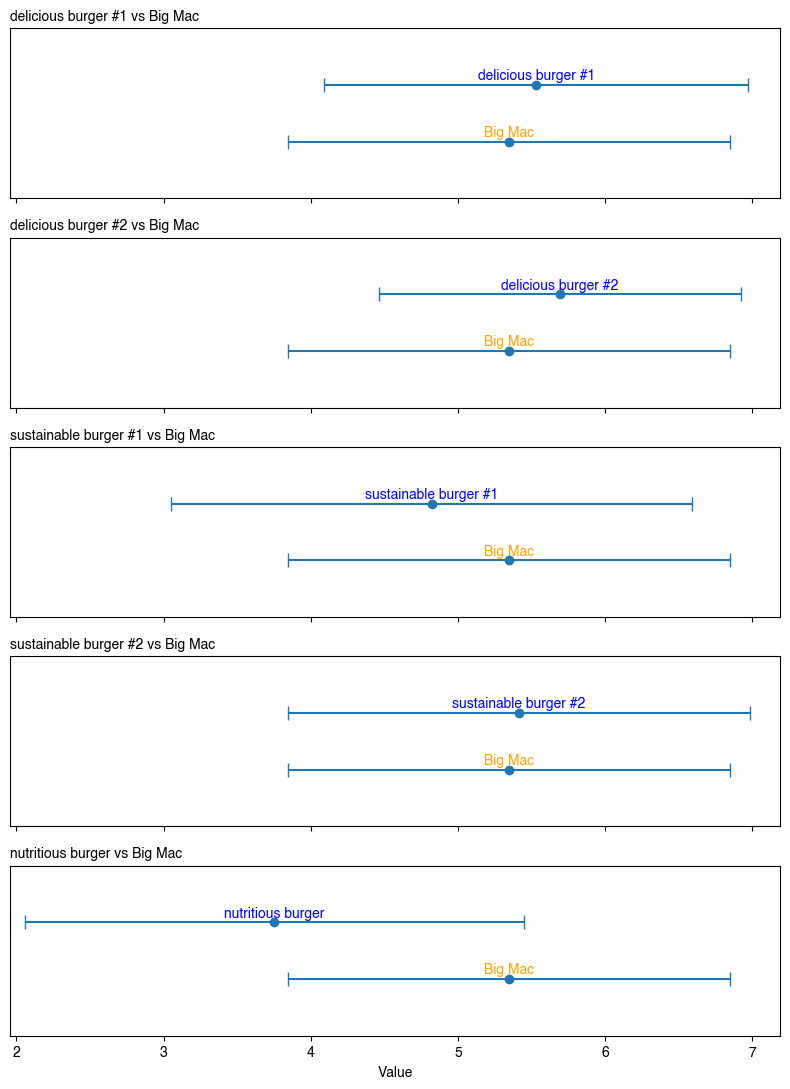

In [130]:
fig, axes = plt.subplots(
    nrows=len(compare_cols),
    ncols=1,
    figsize=(8, 2.2 * len(compare_cols)),
    sharex=True
)

for ax, col in zip(axes, compare_cols):
    # Clean numeric data
    data_col = pd.to_numeric(data[col], errors="coerce").dropna()
    data_ref = pd.to_numeric(data[reference_col], errors="coerce").dropna()

    # Compute means
    mean_col = data_col.mean()
    mean_ref = data_ref.mean()

    # Compute errors (standard deviation)
    err_col = data_col.std()
    err_ref = data_ref.std()

    # Plot points + horizontal error bars
    ax.errorbar(
        x=[mean_ref, mean_col],          # x-position = mean
        y=[0, 1],                        # single horizontal line (stacked)
        xerr=[err_ref, err_col],          # horizontal error bars
        fmt='o',                          # point marker
        capsize=5,
        # color=['orange', 'blue']
    )

    ax.set_yticks([])
    ax.set_yticklabels([])
    ax.set_title(f"{col} vs Big Mac", loc="left", fontsize=10)
    ax.set_xlim(
        min(mean_ref - err_ref, mean_col - err_col) * 0.95,
        max(mean_ref + err_ref, mean_col + err_col) * 1.05
    )

    # Add labels for the points
    ax.text(mean_ref, 0.1, "Big Mac", ha="center", color="orange")
    ax.text(mean_col, 1.1, col, ha="center", color="blue")

    ax.set(ylim=[-1,2])
axes[-1].set_xlabel("Value")
plt.tight_layout()
plt.show()

# 2. Plotting the most different aspect of each burger wrt the big mac

## 2.1. Delicious burger #1

Text(0.5, 0.98, 'Delicious Burger 1')

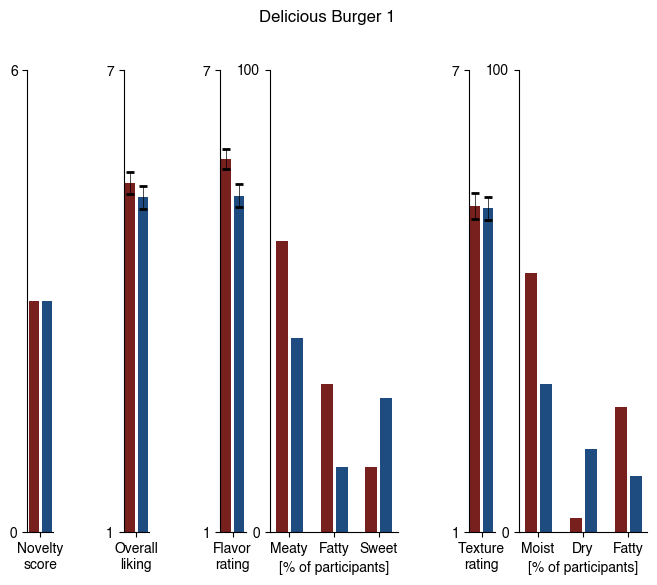

In [160]:
fig = plt.figure(figsize=(8, 6))
n_partc = 100 

# 10 plots + 9 spacers
widths = [
    1, 2.0,
    1, 2.0,
    1, 0.2,
    5, 2.0,
    1, 0.2,
    5,
]
gs = GridSpec(1, len(widths), figure=fig, width_ratios=widths)
ax = []
for i in range(0, len(widths), 2):
    ax.append(fig.add_subplot(gs[0, i]))

color = [np.array((119, 32, 29))/256,np.array((30, 76, 128))/256]

column = 'delicious burger #1'
column_print = 'Delicious Burger 1'

# 1 design criterion
criterion_vals = [3,3]
ax[0].bar([0,1], criterion_vals, color=color)

# 2 overall_liking
overall_1, overall_2 = data_overall[[column, 'big mac']].to_numpy().T
overall_1, overall_2 = numeric_only(overall_1), numeric_only(overall_2)
err_1, err_2 = overall_1.std()/np.sqrt(n_partc), overall_2.std()/np.sqrt(n_partc)
overall_1, overall_2 = overall_1.mean(), overall_2.mean()
overall = [overall_1, overall_2]
ax[1].bar([0,1], overall, color=color, yerr=[err_1, err_2], capsize=3, error_kw=dict(elinewidth=0.5, capthick=2.0))

# 3 flavor
flavor_1, flavor_2 = data_flavor[[column, 'big mac']].to_numpy().T
flavor_1, flavor_2 = numeric_only(flavor_1), numeric_only(flavor_2)
err_1, err_2 = flavor_1.std()/np.sqrt(n_partc), flavor_2.std()/np.sqrt(n_partc)
flavor_1, flavor_2 = flavor_1.mean(), flavor_2.mean()
flavors = [flavor_1, flavor_2]
ax[2].bar([0,1], flavors, color=color, yerr=[err_1, err_2], capsize=3, error_kw=dict(elinewidth=0.5, capthick=2.0))

# 4-6 flavor-related criteria
f1 = to_feature_dict(flavor_features[column])
f2 = to_feature_dict(flavor_features['big mac'])
# Features that exist in BOTH burgers
common_features = set(f1.keys()) & set(f2.keys())
# Absolute differences for common features
diff = {feat: abs(f1[feat] - f2[feat]) for feat in common_features}
diff_sorted = sorted(diff.items(), key=lambda x: x[1], reverse=True)
top3 = diff_sorted[:3]          # list of (feature, diff)
top3_flavor_features = [f for f, _ in top3]
f1_top3 = [f1[feat] for feat in top3_flavor_features]
f2_top3 = [f2[feat] for feat in top3_flavor_features]
ax[3].bar([0,1], [f1_top3[0], f2_top3[0]], color=color)
ax[3].bar([3,4], [f1_top3[1], f2_top3[1]], color=color)
ax[3].bar([6,7], [f1_top3[2], f2_top3[2]], color=color)

# 7 texture
texture_1, texture_2 = data_texture[[column, 'big mac']].to_numpy().T
texture_1, texture_2 = numeric_only(texture_1), numeric_only(texture_2)
err_1, err_2 = texture_1.std()/np.sqrt(n_partc), texture_2.std()/np.sqrt(n_partc)
texture_1, texture_2 = texture_1.mean(), texture_2.mean()
textures = [texture_1, texture_2]
ax[4].bar([0,1], textures, color=color, yerr=[err_1, err_2], capsize=3, error_kw=dict(elinewidth=0.5, capthick=2.0))

# 8-10 texture-related criteria
f1 = to_feature_dict(texture_features[column])
f2 = to_feature_dict(texture_features['big mac'])
# Features that exist in BOTH burgers
common_features = set(f1.keys()) & set(f2.keys())
# Absolute differences for common features
diff = {feat: abs(f1[feat] - f2[feat]) for feat in common_features}
diff_sorted = sorted(diff.items(), key=lambda x: x[1], reverse=True)
top3 = diff_sorted[:3]          # list of (feature, diff)
top3_texture_features = [f for f, _ in top3]
f1_top3 = [f1[feat] for feat in top3_texture_features]
f2_top3 = [f2[feat] for feat in top3_texture_features]
ax[5].bar([0,1], [f1_top3[0], f2_top3[0]], color=color)
ax[5].bar([3,4], [f1_top3[1], f2_top3[1]], color=color)
ax[5].bar([6,7], [f1_top3[2], f2_top3[2]], color=color)


# format the axes
for axi in ax:
    axi.spines['right'].set_visible(False)
    axi.spines['top'].set_visible(False)
    # axi.spines['bottom'].set_visible(False)
    # axi.set(xticks=[])
ax[0].set(ylim=[0,6], yticks=[0,6], xticks=[0.5], xticklabels=['Novelty\nscore'])
ax[1].set(ylim=[1,7], yticks=[1,7], xticks=[0.5], xticklabels=['Overall\nliking'])
ax[2].set(ylim=[1,7], yticks=[1,7], xticks=[0.5], xticklabels=['Flavor\nrating'])
ax[3].set(ylim=[0,100], yticks=[0,100], xticks=[0.5, 3.5, 6.5], xticklabels=top3_flavor_features, xlabel=r'[% of participants]')
ax[4].set(ylim=[1,7], yticks=[1,7], xticks=[0.5], xticklabels=['Texture\nrating'])
ax[5].set(ylim=[0,100], yticks=[0,100], xticks=[0.5, 3.5, 6.5], xticklabels=top3_texture_features, xlabel=r'[% of participants]')
fig.suptitle(column_print)

In [162]:
texture_2

5.198019801980198